# Cora Dataset analysis

## Objective

## Network Setup

In [154]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import networkx.algorithms.community as nx_comm
from collections import Counter
from sklearn.metrics import adjusted_rand_score
import random
import seaborn as sns

In [155]:
# Loading and configuration of the cites bdf file (Edges)
cites = pd.read_csv("./data/cora.cites", sep="\t", header=None, names=["target", "source"])

# Loading file content (Nodes and Attributes)
content = pd.read_csv("./data/cora.content", sep="\t", header=None)

In [156]:
# Initialize Directed Graph
G = nx.DiGraph()
G.add_edges_from(cites[['source', 'target']].values)

# Extract node IDs and labels robustly
paper_ids = content[0]
labels = content.iloc[:, -1]  # Safely select the last column containing the subject/field

label_dict = dict(zip(paper_ids, labels))

# Align graph nodes with dataset nodes
# Ensure isolated papers (nodes with no citations) are included in the graph
G.add_nodes_from(paper_ids)

# Assign the "field" attribute to each node
nx.set_node_attributes(G, label_dict, "field")

# Clean up "ghost" nodes
# Remove nodes that appear in the edge list but have no metadata in the content file
nodes_without_field = [n for n, attr in G.nodes(data=True) if "field" not in attr]

if len(nodes_without_field) > 0:
    print(f"Warning: Removing {len(nodes_without_field)} ghost nodes found in edges but missing in content.")
    G.remove_nodes_from(nodes_without_field)

## 1) Is Academic Knowledge Democratic or Oligarchic?
Is the citation structure distributed equitably among papers, or is it dominated by a small elite of academic "barons"?

### Network Density & Sparsity

In [ ]:
# Getting statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Max possible edges in a Directed Graph: V * (V - 1)
max_possible_edges = num_nodes * (num_nodes - 1)
density = nx.density(G)
sparsity = 1.0 - density

print("--- Network Density & Sparsity ---")
print(f"Total Nodes (V): {num_nodes}")
print(f"Total Edges (E): {num_edges}")
print(f"Maximum Possible Edges: {max_possible_edges}")
print(f"Network Density: {density:.6f}")
print(f"Network Sparsity: {sparsity:.6f} (i.e., {sparsity * 100:.4f}% of potential edges are empty)")

### In-Degree Statistics

=== IN-DEGREE STATISTICS (Citations Received) ===
Mean:               2.0048
Standard Deviation: 5.2182
Minimum:            0
Maximum:            166
99th Percentile Threshold: 18.0 citations
Number of Elite Hubs (>= Threshold): 29 papers (top 1% of the network)


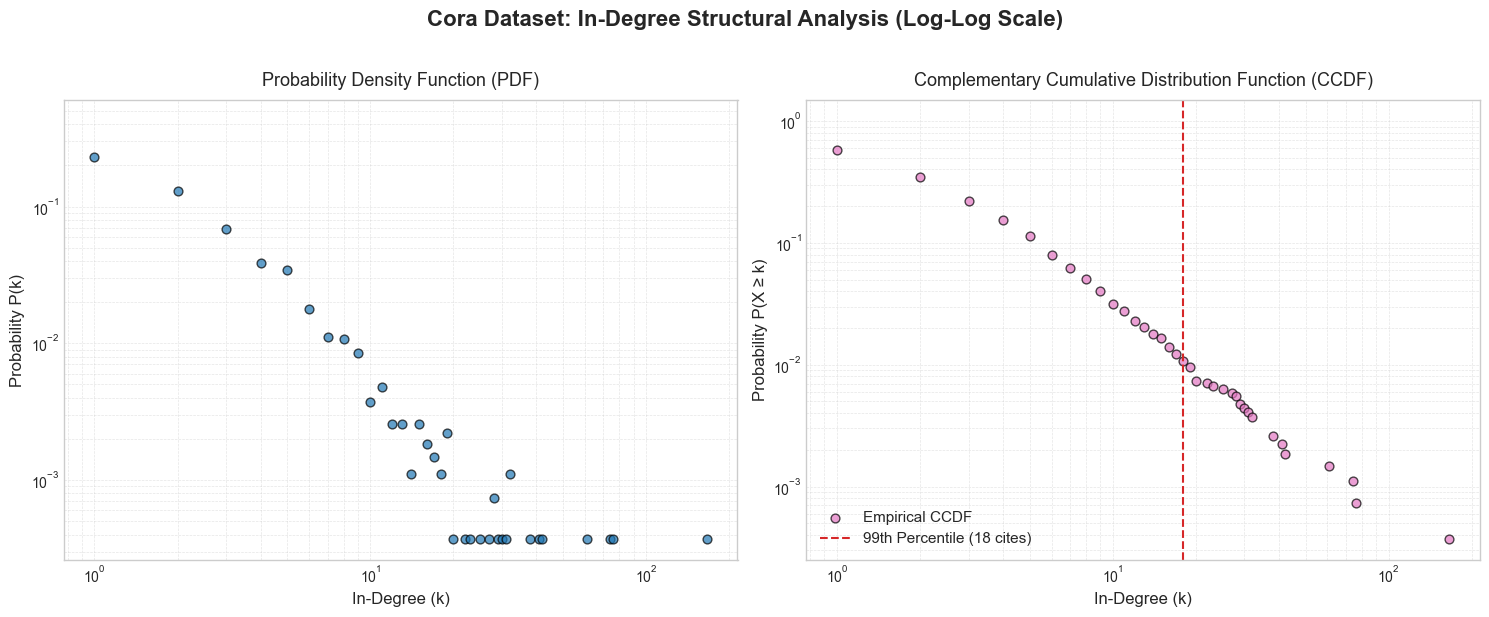

In [168]:
in_degree_dict = dict(G.in_degree())
in_values = np.array(list(in_degree_dict.values()))

print("=== IN-DEGREE STATISTICS (Citations Received) ===")
print(f"Mean:               {np.mean(in_values):.4f}")
print(f"Standard Deviation: {np.std(in_values):.4f}")
print(f"Minimum:            {np.min(in_values)}")
print(f"Maximum:            {np.max(in_values)}")

# Identify the Elite Hubs using the 99th percentile
hub_threshold = np.percentile(in_values, 99)
num_hubs = np.sum(in_values >= hub_threshold)
print(f"99th Percentile Threshold: {hub_threshold:.1f} citations")
print(f"Number of Elite Hubs (>= Threshold): {num_hubs} papers (top 1% of the network)")

### Most Important Papers (Top In-Degree)

In [ ]:
top_papers = sorted(in_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]

total_citations = sum(in_degree_dict.values())

print("=== TOP 10 Most cited papers ===\n")

rows = []
for paper, deg in top_papers:
    rows.append({
        "paper": paper,
        "citazioni": deg,
        "campo": G.nodes[paper].get('field', 'unknown')
    })

df_top = pd.DataFrame(rows)
df_top

### Topological Hub Detection (99th Percentile)

In [ ]:
in_counts = Counter(in_values)
in_degrees_unique = np.array(sorted(in_counts.keys()))
in_degrees_freq = np.array([in_counts[d] for d in in_degrees_unique])

# Probability Density Function (PDF)
in_pdf = in_degrees_freq / len(in_values)

# --- 2. Complementary Cumulative Distribution Function (CCDF) ---
# CCDF calculation: For each degree k, find the fraction of nodes with degree >= k
# Using a clean numpy vectorization approach
in_ccdf = np.array([np.sum(in_values >= k) / len(in_values) for k in in_degrees_unique])


# --- 3. Set up the Plotting Environment ---
plt.style.use('seaborn-v0_8-whitegrid')
# Creating a 1x2 subplot to show PDF and CCDF side-by-side for a rigorous scientific report
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Probability Density Function (PDF)
axes[0].scatter(in_degrees_unique, in_pdf, color='#1f77b4', alpha=0.7, edgecolors='k', s=40, label='Empirical PDF')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Probability Density Function (PDF)', fontsize=13, pad=10)
axes[0].set_xlabel('In-Degree (k)', fontsize=12)
axes[0].set_ylabel('Probability P(k)', fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Subplot 2: Complementary Cumulative Distribution Function (CCDF)
axes[1].scatter(in_degrees_unique, in_ccdf, color='#e377c2', alpha=0.7, edgecolors='k', s=40, label='Empirical CCDF')
# Draw a vertical line representing the 99th percentile (The Oligarchy Threshold)
axes[1].axvline(x=hub_threshold, color='#d62728', linestyle='--', linewidth=1.5, label=f'99th Percentile ({int(hub_threshold)} cites)')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Complementary Cumulative Distribution Function (CCDF)', fontsize=13, pad=10)
axes[1].set_xlabel('In-Degree (k)', fontsize=12)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=12)
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend(fontsize=11, loc='lower left')

# --- Global adjustments ---
plt.suptitle('Cora Dataset: In-Degree Structural Analysis (Log-Log Scale)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot
# import os; os.makedirs('./images', exist_ok=True)
plt.savefig('./images/cora_degree_distribution_clean.png', dpi=300, bbox_inches='tight')
plt.show()

### Baseline check (Erdős-Rényi Graph)

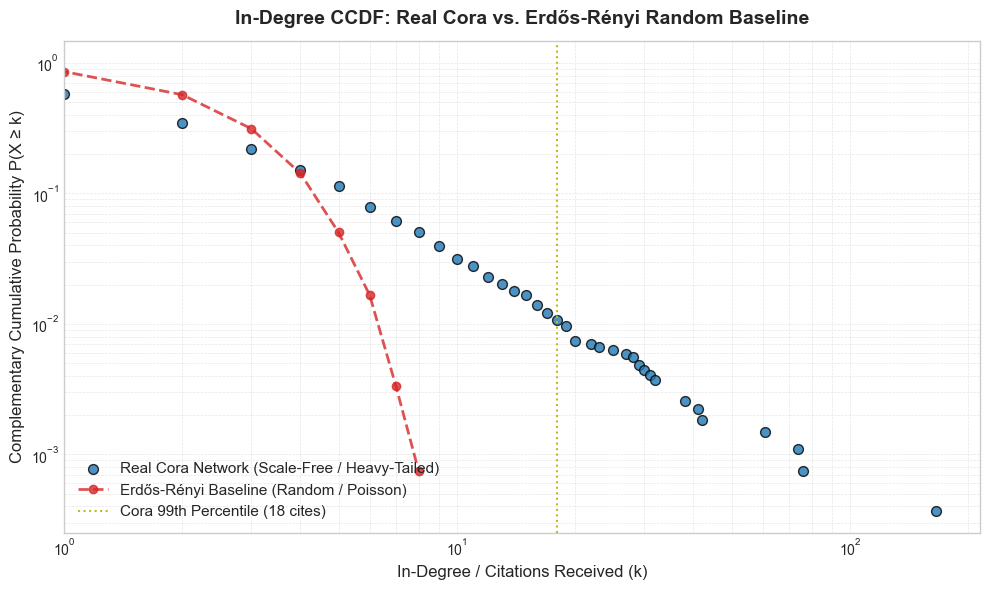

In [169]:
from collections import Counter
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Extract Cora Real In-Degrees ---
in_degree_dict = dict(G.in_degree())
in_values = np.array(list(in_degree_dict.values()))
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Target unique degrees for Cora
in_counts = Counter(in_values)
cora_degrees_unique = np.array(sorted(in_counts.keys()))
cora_ccdf = np.array([np.sum(in_values >= k) / num_nodes for k in cora_degrees_unique])

# Identify the 99th percentile threshold for Cora
hub_threshold = np.percentile(in_values, 99)

# --- 2. Generate Erdős-Rényi Baseline Model ---
# Probability of an edge: E / (V * (V-1))
p_edge = num_edges / (num_nodes * (num_nodes - 1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)

# Extract Erdős-Rényi In-Degrees
erdos_values = np.array([d for n, d in G_erdos.in_degree()])
erdos_counts = Counter(erdos_values)
erdos_degrees_unique = np.array(sorted(erdos_counts.keys()))
erdos_ccdf = np.array([np.sum(erdos_values >= k) / num_nodes for k in erdos_degrees_unique])

# --- 3. Plotting the Scientific Comparison ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Plot Cora (Scale-Free Power Law)
plt.scatter(cora_degrees_unique, cora_ccdf, color='#1f77b4', alpha=0.8, edgecolors='k', s=50,
            label='Real Cora Network (Scale-Free / Heavy-Tailed)')

# Plot Erdős-Rényi (Poisson / Random)
plt.plot(erdos_degrees_unique, erdos_ccdf, color='#d62728', linestyle='--', linewidth=2, marker='o', alpha=0.8,
         label='Erdős-Rényi Baseline (Random / Poisson)')

# Highlight the 99th Percentile of Cora
plt.axvline(x=hub_threshold, color='#bcbd22', linestyle=':', linewidth=1.5,
            label=f'Cora 99th Percentile ({int(hub_threshold)} cites)')

# Log-Log scale configuration
plt.xscale('log')
plt.yscale('log')

plt.title('In-Degree CCDF: Real Cora vs. Erdős-Rényi Random Baseline', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('In-Degree / Citations Received (k)', fontsize=12)
plt.ylabel('Complementary Cumulative Probability P(X ≥ k)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, loc='lower left')

# Adjust limits slightly to frame the visualization cleanly
plt.xlim(left=1)
plt.tight_layout()

# Save the comparative graph
plt.savefig('./images/cora_vs_erdos_ccdf.png', dpi=300, bbox_inches='tight')
plt.show()

## 2) Milestone Papers vs. Literature Reviews: How Do They Behave?
How can we mathematically distinguish a groundbreaking paper that founded a discipline from a paper that simply did an excellent job summarizing existing literature?

### Out-Degree Statistics

In [ ]:
# --- 1. Degree Computations (In vs Out) ---
in_values = np.array([d for n, d in G.in_degree()])
out_values = np.array([d for n, d in G.out_degree()])

print("=== IN-DEGREE STATISTICS (Citations Received) ===")
print(f"Mean: {np.mean(in_values):.4f} | Max: {np.max(in_values)} | Std: {np.std(in_values):.4f}")

print("\n=== OUT-DEGREE STATISTICS (References Made) ===")
print(f"Mean: {np.mean(out_values):.4f} | Max: {np.max(out_values)} | Std: {np.std(out_values):.4f}")

### In-Degree vs Out-Degree CCDF Comparison

=== IN-DEGREE STATISTICS (Citations Received) ===
Mean: 2.0048 | Max: 166 | Std: 5.2182

=== OUT-DEGREE STATISTICS (References Made) ===
Mean: 2.0048 | Max: 5 | Std: 1.4784

=== TOP 5 ACADEMIC AUTHORITIES (Milestone Papers) ===
 node_id              field  in_degree  authority_score
      35 Genetic_Algorithms        166         0.321356
   82920 Genetic_Algorithms         23         0.034380
   85352 Genetic_Algorithms         16         0.026273
    1688 Genetic_Algorithms         15         0.020977
  287787 Genetic_Algorithms         10         0.019740

=== TOP 5 ACADEMIC HUBS (Literature Reviews) ===
 node_id              field  out_degree  hub_score
 1152421 Genetic_Algorithms           4   0.006598
 1153280 Genetic_Algorithms           4   0.006598
 1154459 Genetic_Algorithms           4   0.006598
 1153943 Genetic_Algorithms           5   0.006485
 1119708 Genetic_Algorithms           5   0.006336


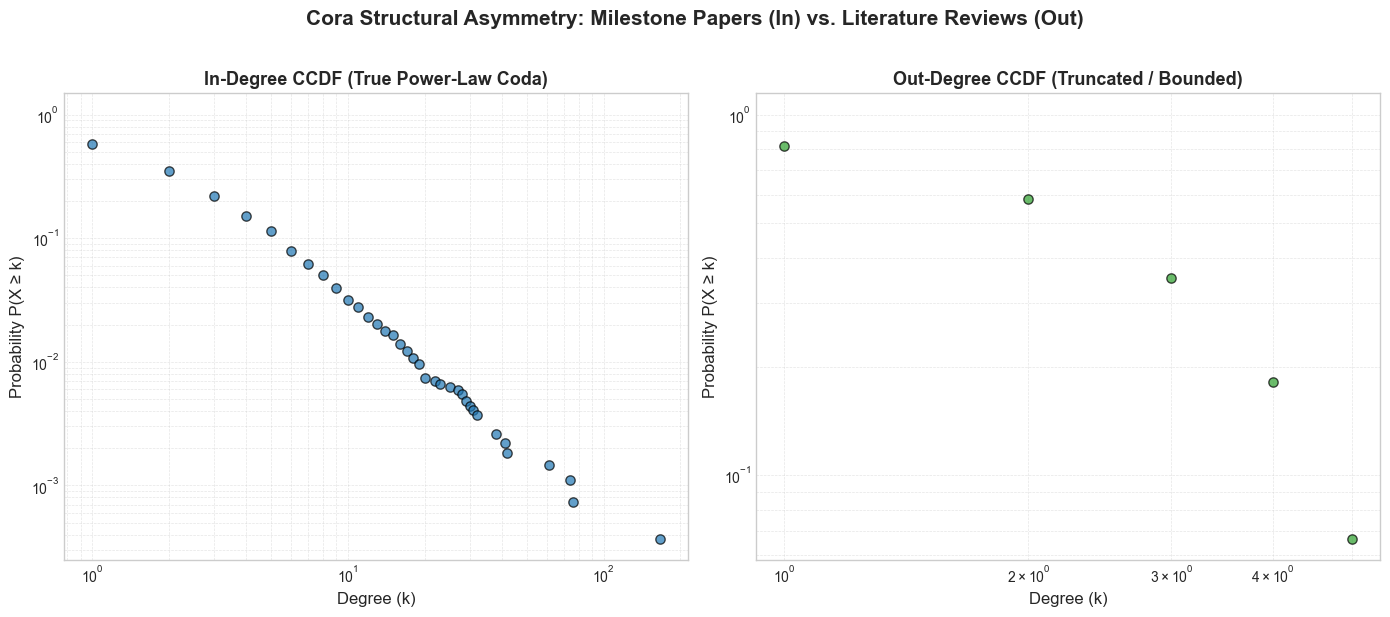

In [170]:
# Compute CCDF for In-Degree
in_counts = Counter(in_values)
in_deg_unique = np.array(sorted(in_counts.keys()))
in_ccdf = np.array([np.sum(in_values >= k) / len(in_values) for k in in_deg_unique])

# Compute CCDF for Out-Degree
out_counts = Counter(out_values)
out_deg_unique = np.array(sorted(out_counts.keys()))
out_ccdf = np.array([np.sum(out_values >= k) / len(out_values) for k in out_deg_unique])

# --- 3. Plotting: The Structural Asymmetry (In vs Out CCDF) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: In-Degree CCDF (Authorities)
axes[0].scatter(in_deg_unique, in_ccdf, color='#1f77b4', alpha=0.7, edgecolors='k', s=45, label='In-Degree (Citations)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('In-Degree CCDF (True Power-Law Coda)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Degree (k)', fontsize=12)
axes[0].set_ylabel('Probability P(X ≥ k)', fontsize=12)
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Subplot 2: Out-Degree CCDF (Hubs)
axes[1].scatter(out_deg_unique, out_ccdf, color='#2ca02c', alpha=0.7, edgecolors='k', s=45, label='Out-Degree (References)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Out-Degree CCDF (Truncated / Bounded)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Degree (k)', fontsize=12)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=12)
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.suptitle('Cora Structural Asymmetry: Milestone Papers (In) vs. Literature Reviews (Out)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('./images/cora_hits_asymmetry.png', dpi=300, bbox_inches='tight')
plt.show()

### Hubs

In [ ]:
hub_threshold = np.percentile(in_degrees, 99)

degree_hubs = [node for node, deg in G.in_degree() if deg >= hub_threshold]

print("=== DEGREE HUBS DETECTION (Top 1% Most Cited) ===")
print(f"In-Degree Threshold for Hubs (99th percentile): {hub_threshold}")
print(f"Number of Hub Nodes Detected: {len(degree_hubs)} out of {G.number_of_nodes()}")

top_hub = max(G.in_degree(), key=lambda x: x[1])
print(f"The Ultimate Hub is Paper ID '{top_hub[0]}' with {top_hub[1]} citations.")
print(f"This single node is connected to {top_hub[1] / G.number_of_edges() * 100:.2f}% of all edges in the network.")

hub_fields = [G.nodes[node].get('field', 'Unknown') for node in degree_hubs]
from collections import Counter
hub_field_distribution = Counter(hub_fields)

print("\n=== FIELD DISTRIBUTION AMONG DETECTED HUBS ===")
for field, count in hub_field_distribution.most_common():
    print(f"Field: {field:<25} | Number of Hubs: {count}")

### PageRank Centrality

In [ ]:
pagerank = nx.pagerank(G)

top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

print("=== TOP 10 NODI PER PAGERANK ===\n")

rows = []
for node, score in top_pr:
    rows.append({
        "nodo": node,
        "pagerank": score,
        "in_degree": G.in_degree(node),
        "campo": G.nodes[node].get('field', 'unknown')
    })

df_pr = pd.DataFrame(rows).sort_values("pagerank", ascending=False)
df_pr

### Hubs and Authorities

In [ ]:
# --- 2. HITS Algorithm (Hubs and Authorities) ---
# max_iter=500 to guarantee convergence on the citation network structure
hubs_score, authorities_score = nx.hits(G, max_iter=500)

# Convert to pandas for fast ranking and inspection
df_hits = pd.DataFrame({
    "node_id": list(G.nodes()),
    "field": [G.nodes[n].get("field") for n in G.nodes()],
    "in_degree": in_values,
    "out_degree": out_values,
    "authority_score": [authorities_score[n] for n in G.nodes()],
    "hub_score": [hubs_score[n] for n in G.nodes()]
})

print("\n=== TOP 5 ACADEMIC AUTHORITIES (Milestone Papers) ===")
print(df_hits.sort_values("authority_score", ascending=False).head(5)[["node_id", "field", "in_degree", "authority_score"]].to_string(index=False))

print("\n=== TOP 5 ACADEMIC HUBS (Literature Reviews) ===")
print(df_hits.sort_values("hub_score", ascending=False).head(5)[["node_id", "field", "out_degree", "hub_score"]].to_string(index=False))

## 3) Does Science Advance in Isolated Silos or via Cross-Disciplinary Contamination?

### Attribute Assortativity Coefficient ($r$)

In [ ]:
assortativity_field = nx.attribute_assortativity_coefficient(G, "field")

print("=== NETWORK ASSORTATIVITY ANALYSIS ===")
print(f"Attribute Assortativity Coefficient (Field): {assortativity_field:.4f}")

if assortativity_field > 0.2:
    print("Interpretation: The network is highly assortative. Papers strongly prefer to cite within their own field.")
elif assortativity_field < -0.2:
    print("Interpretation: The network is disassortative. Cross-field citations are dominant.")
else:
    print("Interpretation: The network is neutral. Field categories do not heavily dictate citation patterns.")

### Attribute Mixing Matrix

In [ ]:
# Mixing matrix preparation
fields_list = sorted(list(set(nx.get_node_attributes(G, "field").values())))
mixing_matrix = nx.attribute_mixing_matrix(G, "field", mapping={f: i for i, f in enumerate(fields_list)})
mixing_df = pd.DataFrame(mixing_matrix, index=fields_list, columns=fields_list)

### Mixing Matrix Heatmap

In [ ]:
# --- 3. Visualize the Mixing Matrix via Heatmap ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))
sns.heatmap(mixing_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, square=True)
plt.title("Cora Dataset: Field-to-Field Citation Mixing Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Target Field (Cited Paper)", fontsize=12)
plt.ylabel("Source Field (Citing Paper)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('./images/cora_assortativity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Analytical Homophily Test ($\rho \ll 2pq$)

In [176]:
total_edges = G.number_of_edges()
cross_edges_count = 0

for u, v in G.edges():
    if G.nodes[u].get("field") != G.nodes[v].get("field"):
        cross_edges_count += 1

rho = cross_edges_count / total_edges

node_fields = [G.nodes[n].get("field") for n in G.nodes() if G.nodes[n].get("field") is not None]
field_counts = pd.Series(node_fields).value_counts()
field_probabilities = field_counts / len(node_fields)

expected_cross_fraction = 1.0 - np.sum(field_probabilities ** 2)

print("=== ANALYTICAL HOMOPHILY TEST (ρ vs 2pq) ===")
print(f"Observed Cross-Edges Fraction (ρ):          {rho:.4%}")
print(f"Theoretical Expected Cross Fraction (2pq):  {expected_cross_fraction:.4%}")

# --- 3. Mathematical Validation ---
print("\n--- Analytical Conclusion ---")
if rho < expected_cross_fraction:
    ratio = rho / expected_cross_fraction
    print(f"Conclusion: Homophily Confirmed! (ρ << 2pq)")
    print(f"The actual cross-field citation rate is only {ratio:.2%} of what random chance predicts.")
else:
    print("Conclusion: No Homophily. The network citations are random or heterophilous.")

=== ANALYTICAL HOMOPHILY TEST (ρ vs 2pq) ===
Observed Cross-Edges Fraction (ρ):          18.6222%
Theoretical Expected Cross Fraction (2pq):  82.0432%

--- Analytical Conclusion ---
Conclusion: Homophily Confirmed! (ρ << 2pq)
The actual cross-field citation rate is only 22.70% of what random chance predicts.


## If the Network is Segregated into Silos, How Does Information Ever Circulate Globally?

Small-World Analysis (Average Path Length $L_{real}$ and Small-Worldness Index $\sigma > 1$).Betweenness Centrality (identifying structural brokers).Neighborhood Overlap and Granovetter's Theory of Weak Ties (Local Bridges with overlap = 0).

### Connected Components and Giant Component

In [ ]:
# Getting the giant component
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))

print(f"Number of Strongly Connected Components (SCC): {len(scc)}")
print(f"Number of Weakly Connected Components (WCC): {len(wcc)}")

# Sizes of the largest components (Giant Components)
largest_scc_size = len(max(scc, key=len))
largest_wcc_size = len(max(wcc, key=len))

print(f"Largest SCC (Giant Component) Size: {largest_scc_size} nodes ({largest_scc_size/num_nodes*100:.2f}%)")
print(f"Largest WCC (Giant Component) Size: {largest_wcc_size} nodes ({largest_wcc_size/num_nodes*100:.2f}%)")

gcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_gcc_undirected = G.subgraph(gcc_nodes).to_undirected()

n_gcc = G_gcc_undirected.number_of_nodes()
e_gcc = G_gcc_undirected.number_of_edges()

print(f"Analyzing the Giant Connected Component (GCC)...")
print(f"GCC Nodes: {n_gcc} | GCC Edges: {e_gcc}")

### Reciprocity

In [ ]:
global_reciprocity = nx.overall_reciprocity(G)

print("--- Network Reciprocity Analysis ---")
print(f"Global Reciprocity Coefficient: {global_reciprocity:.6f}")

reciprocal_edges = []
for u, v in G.edges():
    if G.has_edge(v, u) and (v, u) not in reciprocal_edges:
        reciprocal_edges.append((u, v))

print(f"Number of Reciprocal Edge Pairs: {len(reciprocal_edges)}")

# --- 3. Inspect Reciprocal Papers ---
# Display the fields of reciprocating papers to see if they belong to the same domain
if len(reciprocal_edges) > 0:
    print("\n--- Sample of Reciprocal Papers and their Fields ---")
    # Show up to top 5 examples
    for u, v in reciprocal_edges[:5]:
        field_u = G.nodes[u].get('field', 'Unknown')
        field_v = G.nodes[v].get('field', 'Unknown')
        print(f"Paper {u} ({field_u}) <---> Paper {v} ({field_v})")
else:
    print("\nNo reciprocal edges found in the network.")

### Average Shortest Path Length ($L_{real}$)

In [178]:
L_real = nx.average_shortest_path_length(G_gcc_undirected)
print(f"Average Shortest Path Length (L_real):    {L_real:.4f} steps")
k_avg = (2 * e_gcc) / n_gcc
L_rand = np.log(n_gcc) / np.log(k_avg)
print(f"Expected Random Path Length (L_rand):     {L_rand:.4f} steps")

Average Shortest Path Length (L_real):    6.3110 steps
Expected Random Path Length (L_rand):     5.5604 steps


### Average Clustering Coefficient ($C_{real}$)

In [179]:
C_rand = k_avg / n_gcc
C_real = nx.average_clustering(G_gcc_undirected)
print(f"Average Clustering Coefficient (C_real): {C_real:.4f}")
print(f"Expected Random Clustering (C_rand):      {C_rand:.4f}")

Average Clustering Coefficient (C_real): 0.2376
Expected Random Clustering (C_rand):      0.0016


### Small-Worldness Index ($\sigma$)

In [ ]:
# --- 4. Calculate Small-World Coefficients ---
# Gamma (Clustering ratio) -> Must be >> 1
gamma = C_real / C_rand
# Lambda (Path length ratio) -> Must be ~= 1
lam = L_real / L_rand

# Small-Worldness Index (Sigma) -> Must be > 1
sigma = gamma / lam

print(f"\n--- Small-World Ratios & Index ---")
print(f"Gamma  (C_real / C_rand): {gamma:.4f}  (Should be >> 1)")
print(f"Lambda (L_real / L_rand): {lam:.4f}  (Should be close to 1)")
print(f"Sigma  (Small-Worldness Index): {sigma:.4f}")


print("\n--- Small-World Conclusion ---")
if sigma > 1.0 and gamma > 1.0 and abs(lam - 1.0) < 0.5:
    print(f"Conclusion: Confirmed! Cora exhibits strong Small-World properties (Sigma = {sigma:.2f} > 1).")
    print(f"Even though papers are tightly clustered by domain, you can traverse the entire")
    print(f"academic network in fewer than {np.ceil(L_real)} citation steps on average.")
else:
    print("Conclusion: The network does not strictly satisfy the Small-World criteria.")

### La Tabella Comparativa Finale (Cora vs ER vs Configuration Model)

In [ ]:
# --- Setup metrics collection ---
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Since baseline generation can be heavy, we compute basic undirected metrics for comparison
G_real_und = G.to_undirected()

# 1. Compute Real Network Metrics
metrics_real = {
    "Model": "Real Cora Network",
    "Nodes": num_nodes,
    "Edges": num_edges,
    "Avg Clustering Coefficient": nx.average_clustering(G_real_und),
    "Transitivity": nx.transitivity(G_real_und),
    "Number of WCC": nx.number_weakly_connected_components(G),
    "Global Reciprocity": nx.overall_reciprocity(G)
}

# --- 2. Baseline Model A: Erdős-Rényi Random Graph ---
# Probability of an edge: E / (V * (V-1))
p_edge = num_edges / (num_nodes * (num_nodes - 1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)
G_erdos_und = G_erdos.to_undirected()

metrics_erdos = {
    "Model": "Erdős-Rényi (Random)",
    "Nodes": G_erdos.number_of_nodes(),
    "Edges": G_erdos.number_of_edges(),
    "Avg Clustering Coefficient": nx.average_clustering(G_erdos_und),
    "Transitivity": nx.transitivity(G_erdos_und),
    "Number of WCC": nx.number_weakly_connected_components(G_erdos),
    "Global Reciprocity": nx.overall_reciprocity(G_erdos)
}

# --- 3. Baseline Model B: Directed Configuration Model ---
# This preserves the exact in-degree and out-degree sequences of Cora
in_deg_sequence = [d for n, d in G.in_degree()]
out_deg_sequence = [d for n, d in G.out_degree()]

# Generate the configuration model (creates a multigraph, then we remove self-loops/parallel edges)
G_config_multi = nx.directed_configuration_model(in_deg_sequence, out_deg_sequence, seed=42)
G_config = nx.DiGraph(G_config_multi) # Convert to simple DiGraph
G_config.remove_edges_from(nx.selfloop_edges(G_config)) # Clean up self-loops
G_config_und = G_config.to_undirected()

metrics_config = {
    "Model": "Configuration Model",
    "Nodes": G_config.number_of_nodes(),
    "Edges": G_config.number_of_edges(),
    "Avg Clustering Coefficient": nx.average_clustering(G_config_und),
    "Transitivity": nx.transitivity(G_config_und),
    "Number of WCC": nx.number_weakly_connected_components(G_config),
    "Global Reciprocity": nx.overall_reciprocity(G_config)
}

# --- 4. Generate and Print the Comparison Table ---
df_comparison = pd.DataFrame([metrics_real, metrics_erdos, metrics_config])

print("=== BASELINE MODELS COMPARISON TABLE ===")
print(df_comparison.to_string(index=False, formatters={
    "Avg Clustering Coefficient": "{:,.4f}".format,
    "Transitivity": "{:,.4f}".format,
    "Global Reciprocity": "{:,.6f}".format
}))

### Betweenness Centrality

In [ ]:
betweenness = nx.betweenness_centrality(G)

rows = []
for node, score in betweenness.items():
    rows.append({
        "nodo": node,
        "betweenness": score,
        "in_degree": G.in_degree(node),
        "campo": G.nodes[node].get('field', 'unknown')
    })

df_bc = pd.DataFrame(rows)
df_bc = df_bc.sort_values("betweenness", ascending=False).head(10)

df_bc

### Neighborhood Overlap (Teoria di Granovetter)

In [ ]:
# Convert to undirected to calculate neighborhood overlap properly
G_und = G.to_undirected()
total_edges = G_und.number_of_edges()

edge_data = []
local_bridges_count = 0

for u, v in G_und.edges():
    # Get neighbors for both nodes
    neighbors_u = set(G_und.neighbors(u))
    neighbors_v = set(G_und.neighbors(v))

    # Intersection and Union (excluding the nodes themselves)
    intersection = len(neighbors_u.intersection(neighbors_v))
    union = len(neighbors_u.union(neighbors_v)) - 2 # -2 to exclude u and v from union

    # Neighborhood Overlap formula
    overlap = intersection / union if union > 0 else 0.0

    # A local bridge has an overlap of 0 (no mutual friends)
    is_local_bridge = (overlap == 0.0)
    if is_local_bridge:
        local_bridges_count += 1

    # Check if the edge crosses different fields (Interdisciplinary edge)
    is_cross_field = (G.nodes[u].get("field") != G.nodes[v].get("field"))

    edge_data.append({
        "edge": (u, v),
        "overlap": overlap,
        "is_local_bridge": is_local_bridge,
        "is_cross_field": is_cross_field
    })

df_edges = pd.DataFrame(edge_data)

# --- Print Insights in English ---
print("=== NEIGHBORHOOD OVERLAP & BRIDGES ANALYSIS ===")
print(f"Total Undirected Edges: {total_edges}")
print(f"Local Bridges Detected (Overlap = 0): {local_bridges_count} ({local_bridges_count/total_edges:.2%})")

# Calculate average overlap for inside-field vs cross-field edges
avg_overlap_inside = df_edges[df_edges["is_cross_field"] == False]["overlap"].mean()
avg_overlap_cross = df_edges[df_edges["is_cross_field"] == True]["overlap"].mean()

print(f"\n--- Granovetter's Weak Ties Validation ---")
print(f"Avg Overlap for Same-Field Citations (Strong Ties):  {avg_overlap_inside:.4f}")
print(f"Avg Overlap for Cross-Field Citations (Weak Ties):  {avg_overlap_cross:.4f}")

# Percentage of local bridges that are cross-field
bridges_df = df_edges[df_edges["is_local_bridge"] == True]
cross_field_bridges_pct = bridges_df["is_cross_field"].mean()
print(f"\nPercentage of Local Bridges that connect DIFFERENT fields: {cross_field_bridges_pct:.2%}")

## 5) If We Inject an Innovative Idea into the Network, What is Its Fate?

### Louvain Community Detection

In [ ]:
G_undirected = G.to_undirected()

louvain_partition = nx_comm.louvain_communities(G_undirected, seed=42)

communities = nx_comm.louvain_communities(G.to_undirected(), seed=42)

node_community = {}

for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

nx.set_node_attributes(G, node_community, "community")

modularity_score = nx_comm.modularity(G_undirected, louvain_partition)

print("=== COMMUNITY DETECTION (LOUVAIN ALGORITHM) ===")
print(f"Number of Communities Detected: {len(louvain_partition)}")
print(f"Network Modularity Score (Q):  {modularity_score:.4f}")

nodes_ordered = list(G.nodes())
true_labels = [G.nodes[n].get("field") for n in nodes_ordered]
predicted_labels = [G.nodes[n].get("community") for n in nodes_ordered]

ari_score = adjusted_rand_score(true_labels, predicted_labels)
print(f"Adjusted Rand Index (ARI):     {ari_score:.4f}")

print("\n=== DETECTED COMMUNITIES COMPOSITION ===")
df_nodes = pd.DataFrame({
    "node_id": nodes_ordered,
    "field": true_labels,
    "community": predicted_labels
})

for comm_id in sorted(df_nodes["community"].unique()):
    comm_subset = df_nodes[df_nodes["community"] == comm_id]
    comm_size = len(comm_subset)

    # Find the dominant field in this structural community
    dominant_field = comm_subset["field"].value_counts().idxmax()
    dominant_field_pct = comm_subset["field"].value_counts().max() / comm_size

    print(f"Community {comm_id:<2} | Size: {comm_size:<4} Nodes | Dominant Field: {dominant_field:<22} ({dominant_field_pct:.2%})")

### Independent Cascade Model (ICM)

In [ ]:
def simulate_independent_cascade(graph, seed_nodes, infection_prob=0.15, max_steps=10):
    """
    Simulates the spread of information using the Independent Cascade Model.
    Returns a list containing the cumulative number of activated nodes at each step.
    """
    activated = set(seed_nodes)
    newly_activated = set(seed_nodes)
    history = [len(activated)]

    for step in range(max_steps):
        next_activated = set()
        for node in newly_activated:
            # In a citation network, information can flow both ways:
            # - Forward: a new paper reads an old one (successors)
            # - Backward: influence propagation (predecessors)
            # We use successors here to simulate the forward walk of an idea
            neighbors = list(graph.successors(node))
            for neighbor in neighbors:
                if neighbor not in activated and neighbor not in next_activated:
                    # Roll a dice for infection
                    if np.random.rand() < infection_prob:
                        next_activated.add(neighbor)

        if not next_activated:
            # Spread stopped early
            while len(history) <= max_steps:
                history.append(len(activated))
            break

        activated.update(next_activated)
        newly_activated = next_activated
        history.append(len(activated))

    return history

### Seed Dependency Test

In [ ]:
# Scenario A: Top Authority (High-influence node found in previous steps)
top_authority = max(dict(G.in_degree()).items(), key=lambda x: x[1])[0]

# Scenario B: Random Paper (Average-influence node)
np.random.seed(42)
random_node = np.random.choice(list(G.nodes()))

# --- 1. Define Seed Nodes for Comparison ---


# --- 2. Run Multiple Simulations to Get Stable Averages ---
num_runs = 50
steps = 10
prob = 0.20 # 20% chance of spreading the idea per link

auth_spread_runs = np.array([simulate_independent_cascade(G, [top_authority], prob, steps) for _ in range(num_runs)])
rand_spread_runs = np.array([simulate_independent_cascade(G, [random_node], prob, steps) for _ in range(num_runs)])

# Calculate mean cascade curves
auth_mean_curve = np.mean(auth_spread_runs, axis=0)
rand_mean_curve = np.mean(rand_spread_runs, axis=0)

# --- 3. Plot the Information Spread Curves ---
plt.figure(figsize=(10, 6))
plt.plot(auth_mean_curve, marker='o', linewidth=2.5, color='#d62728', label=f'Seed: Top Authority (ID: {top_authority})')
plt.plot(rand_mean_curve, marker='s', linewidth=2.5, color='#7f7f7f', label=f'Seed: Random Paper (ID: {random_node})')

plt.title('Information Spread Simulation on Cora (Independent Cascade Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Simulation Time Steps', fontsize=12)
plt.ylabel('Cumulative Number of Influenced Papers', fontsize=12)
plt.xticks(range(steps + 1))
plt.grid(True, ls='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

plt.show()

## Visualizzazione

### JSON generation...

In [180]:
import json
import networkx as nx

# Calcolo metriche necessarie per la visualizzazione
pagerank_scores = nx.pagerank(G)
in_degrees = dict(G.in_degree())

# Community Detection (Louvain) per il filtro di confronto
G_und = G.to_undirected()
louvain_partition = nx_comm.louvain_communities(G_und, seed=42)
node_comm_map = {node: i for i, comm in enumerate(louvain_partition) for node in comm}

d3_data = {"nodes": [], "links": []}

for node in G.nodes():
    d3_data["nodes"].append({
        "id": int(node),
        "field": G.nodes[node].get("field", "Unknown"),
        "community": int(node_comm_map.get(node, 0)),
        "pagerank": float(pagerank_scores.get(node, 0)),
        "in_degree": int(in_degrees.get(node, 0))
    })

for u, v in G.edges():
    # Calcolo rapido del Neighborhood Overlap per marcare i Local Bridges
    nu = set(G_und.neighbors(u))
    nv = set(G_und.neighbors(v))
    union_size = len(nu.union(nv)) - 2
    overlap = len(nu.intersection(nv)) / union_size if union_size > 0 else 0.0

    d3_data["links"].append({
        "source": int(u),
        "target": int(v),
        "is_local_bridge": bool(overlap == 0.0),
        "is_cross_field": bool(G.nodes[u].get("field") != G.nodes[v].get("field"))
    })

with open("cora_d3_data.json", "w") as f:
    json.dump(d3_data, f, indent=2)

print("✅ 'cora_d3_data.json' generato con successo!")

✅ 'cora_d3_data.json' generato con successo!


### Server Launching

In [181]:
import http.server
import socketserver
import threading
import webbrowser

PORT = 8000

# Funzione per inizializzare il server
def start_server():
    # Allow port reuse to avoid 'Address already in use' errors on quick restarts
    socketserver.TCPServer.allow_reuse_address = True
    Handler = http.server.SimpleHTTPRequestHandler

    with socketserver.TCPServer(("", PORT), Handler) as httpd:
        print(f"🌍 Server D3 attivo in background sulla porta {PORT}.")
        print("Puoi continuare a usare il notebook liberamente.")
        httpd.serve_forever()

# Lanciamo il server dentro un Thread asincrono separato
server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

# Apre automaticamente una nuova tab nel tuo browser predefinito all'indirizzo corretto
webbrowser.open(f'http://localhost:{PORT}/index.html')

🌍 Server D3 attivo in background sulla porta 8000.
Puoi continuare a usare il notebook liberamente.


True

127.0.0.1 - - [16/May/2026 17:12:44] "GET /index.html HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 17:12:44] "GET /app.js HTTP/1.1" 200 -
127.0.0.1 - - [16/May/2026 17:12:44] code 404, message File not found
127.0.0.1 - - [16/May/2026 17:12:44] "GET /favicon.ico HTTP/1.1" 404 -
